# Music4All Cold-Start Recommendation: Exploratory Data Analysis

This notebook examines the timestamped Music4All listening history and its associated track metadata.

The analysis focuses on:

- user-history depth;
- repeat-listening behavior;
- track-popularity concentration;
- long-tail catalog structure;
- evidence-based filtering thresholds;
- implications for chronological cold-start evaluation.

Exact duplicate user–track–timestamp events were removed before these summaries were created.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
import numpy as np


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

EDA_DIRECTORY = PROJECT_ROOT / "data" / "interim" / "eda"
FIGURE_DIRECTORY = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
    }
)

In [23]:
dataset_summary = pd.read_csv(
    EDA_DIRECTORY / "dataset_summary.csv"
)
popularity_concentration = pd.read_csv(
    EDA_DIRECTORY / "popularity_concentration.csv"
)
user_thresholds = pd.read_csv(
    EDA_DIRECTORY / "user_thresholds.csv"
)
track_thresholds = pd.read_csv(
    EDA_DIRECTORY / "track_thresholds.csv"
)

user_summary = pd.read_parquet(
    EDA_DIRECTORY / "user_summary.parquet"
)
track_summary = pd.read_parquet(
    EDA_DIRECTORY / "track_summary.parquet"
)
popularity_curve = pd.read_parquet(
    EDA_DIRECTORY / "popularity_curve.parquet"
)

print(f"Users: {len(user_summary):,}")
print(f"Tracks: {len(track_summary):,}")

Users: 14,127
Tracks: 99,596


## 1. Dataset Overview

The cleaned dataset contains more than five million timestamped listening events. Its user histories are sufficiently deep to simulate severe, moderate, and light cold-start conditions while retaining future interactions for evaluation.

In [24]:
display(
    dataset_summary.rename(
        columns={
            "statistic": "Statistic",
            "value": "Value",
        }
    ).style.hide(axis="index")
)

Statistic,Value
Raw listening events,5109592
Exact duplicate events removed,81884
Clean listening events,5027708
Unique users,14127
Unique tracks,99596
Earliest timestamp,2013-12-30 22:42:00
Latest timestamp,2019-03-26 11:57:00
Median events per user,370.0
Median distinct tracks per user,182.0
Median repeat-event rate,0.47912087912087914


## 2. User Activity and Repeat Listening

A cold-start benchmark requires users with enough distinct tracks to reveal a small seed set while preserving later interactions as evaluation targets.

The following distributions measure users’ catalog breadth and their tendency to replay previously heard tracks.

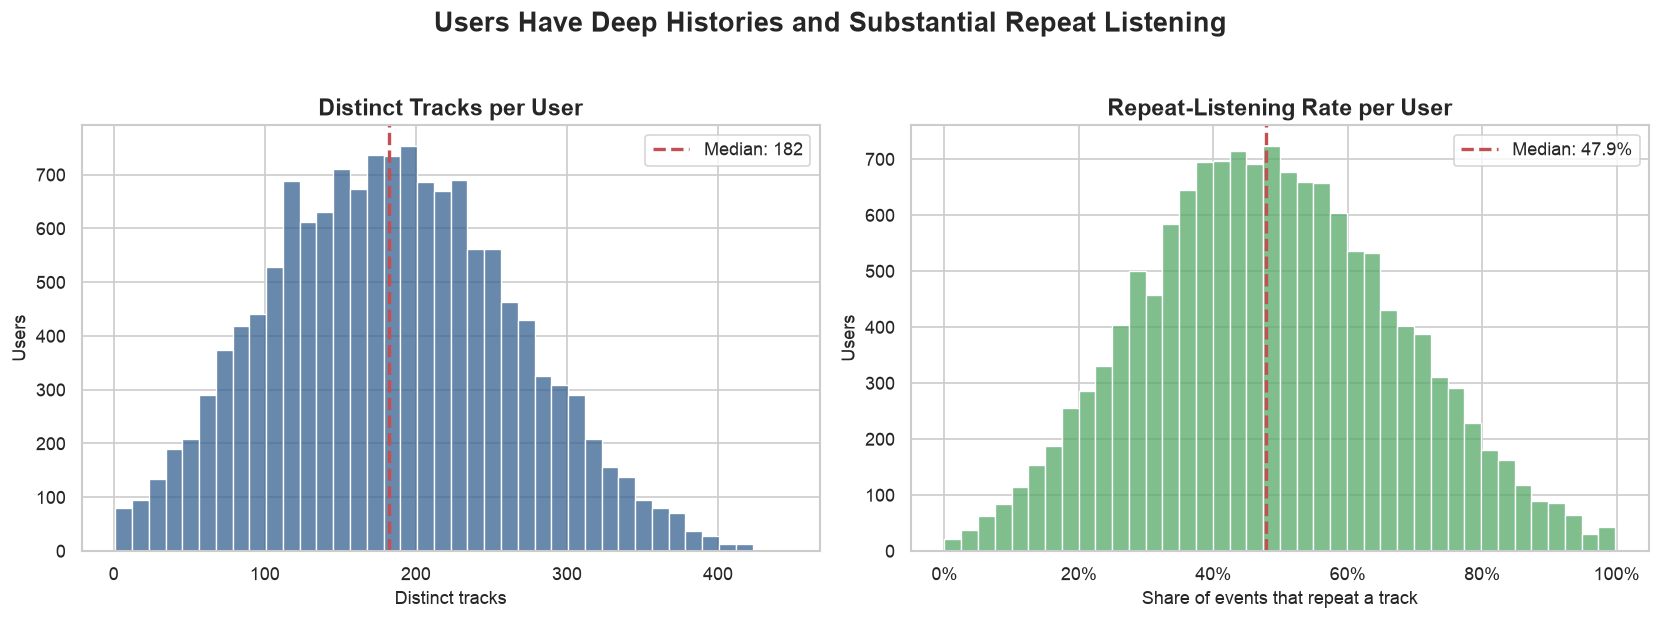

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=user_summary,
    x="distinct_tracks",
    bins=40,
    color="#35618f",
    ax=axes[0],
)

axes[0].axvline(
    user_summary["distinct_tracks"].median(),
    color="#c44e52",
    linestyle="--",
    linewidth=2,
    label=(
        "Median: "
        f"{user_summary['distinct_tracks'].median():.0f}"
    ),
)
axes[0].set(
    title="Distinct Tracks per User",
    xlabel="Distinct tracks",
    ylabel="Users",
)
axes[0].legend()

sns.histplot(
    data=user_summary,
    x="repeat_event_rate",
    bins=40,
    color="#55a868",
    ax=axes[1],
)

axes[1].axvline(
    user_summary["repeat_event_rate"].median(),
    color="#c44e52",
    linestyle="--",
    linewidth=2,
    label=(
        "Median: "
        f"{user_summary['repeat_event_rate'].median():.1%}"
    ),
)
axes[1].set(
    title="Repeat-Listening Rate per User",
    xlabel="Share of events that repeat a track",
    ylabel="Users",
)
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)
axes[1].legend()

fig.suptitle(
    "Users Have Deep Histories and Substantial Repeat Listening",
    fontsize=16,
    fontweight="bold",
    y=1.03,
)
fig.tight_layout()

figure_path = FIGURE_DIRECTORY / "01_user_activity.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

### Findings

- The median user interacted with 182 distinct tracks, leaving ample history for chronological holdout evaluation.
- Approximately 48% of the median user’s events are repeat listens.
- Recommendation evaluation should therefore use distinct tracks when constructing seed sets and held-out targets.
- A minimum requirement of 20 distinct tracks is unlikely to remove many users while ensuring that every evaluated listener has sufficient future history.

## 3. Track Popularity and the Long Tail

Music consumption commonly follows a long-tail distribution: a small number of tracks receive a large share of listening, while most tracks receive relatively little engagement.

This imbalance affects model training because a recommender can achieve superficially strong accuracy by repeatedly suggesting popular music.

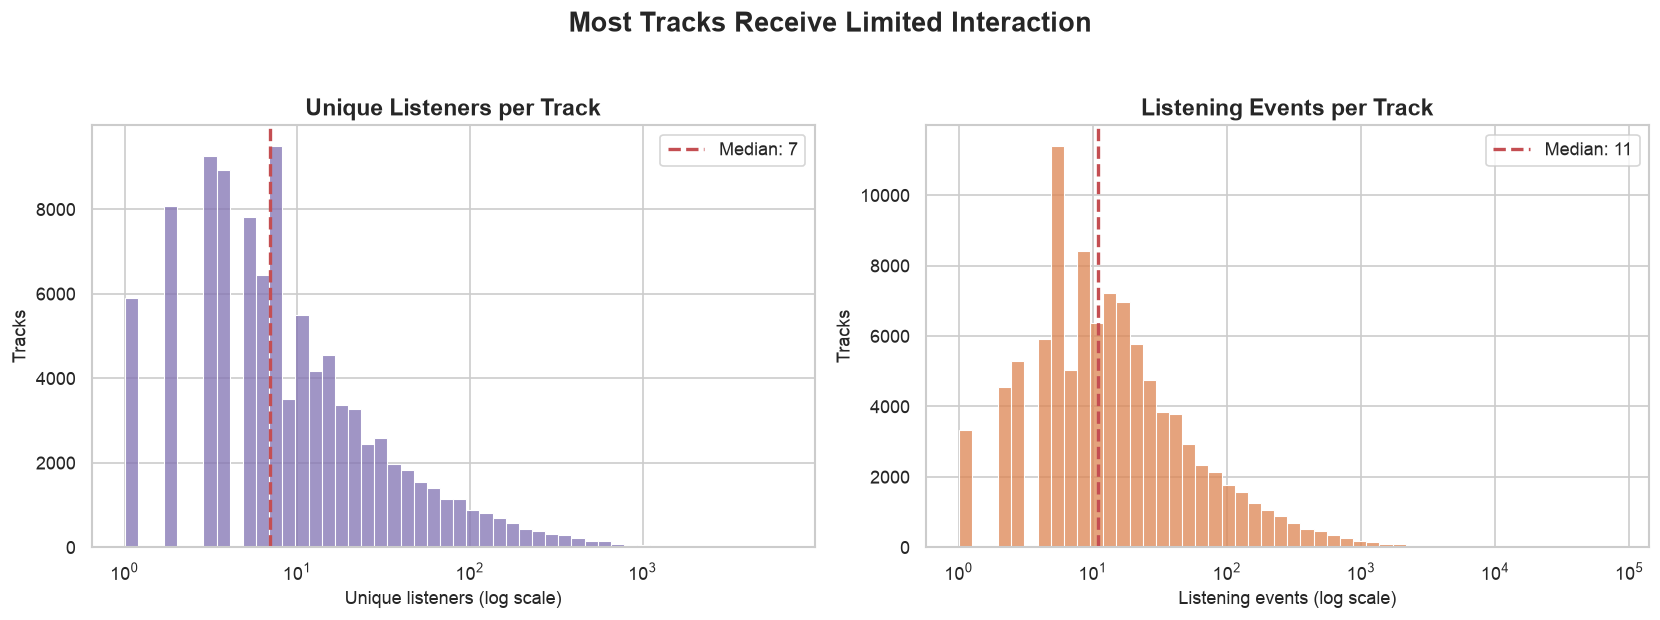

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=track_summary,
    x="unique_listeners",
    bins=50,
    log_scale=True,
    color="#8172b2",
    ax=axes[0],
)
axes[0].axvline(
    track_summary["unique_listeners"].median(),
    color="#c44e52",
    linestyle="--",
    linewidth=2,
    label=(
        "Median: "
        f"{track_summary['unique_listeners'].median():.0f}"
    ),
)
axes[0].set(
    title="Unique Listeners per Track",
    xlabel="Unique listeners (log scale)",
    ylabel="Tracks",
)
axes[0].legend()

sns.histplot(
    data=track_summary,
    x="listening_events",
    bins=50,
    log_scale=True,
    color="#dd8452",
    ax=axes[1],
)
axes[1].axvline(
    track_summary["listening_events"].median(),
    color="#c44e52",
    linestyle="--",
    linewidth=2,
    label=(
        "Median: "
        f"{track_summary['listening_events'].median():.0f}"
    ),
)
axes[1].set(
    title="Listening Events per Track",
    xlabel="Listening events (log scale)",
    ylabel="Tracks",
)
axes[1].legend()

fig.suptitle(
    "Most Tracks Receive Limited Interaction",
    fontsize=16,
    fontweight="bold",
    y=1.03,
)
fig.tight_layout()

figure_path = FIGURE_DIRECTORY / "02_track_activity.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

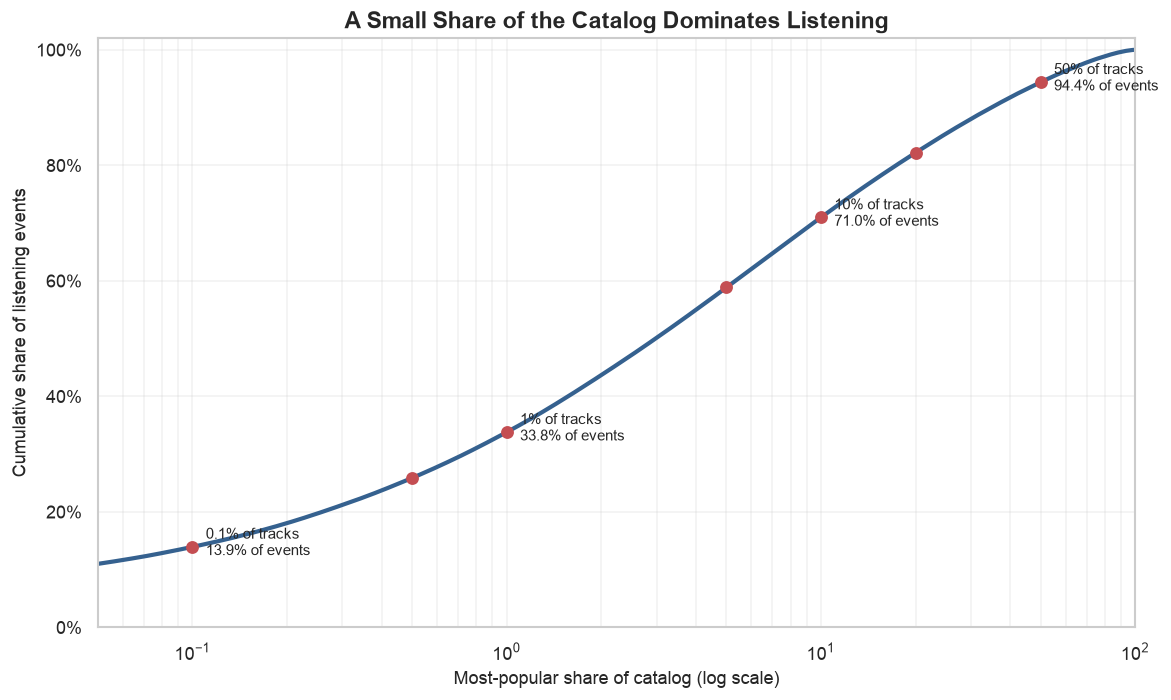

In [27]:
curve = popularity_curve.copy()

curve["catalog_pct"] = curve["catalog_fraction"] * 100
curve["cumulative_event_pct"] = (
    curve["cumulative_event_fraction"] * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=curve,
    x="catalog_pct",
    y="cumulative_event_pct",
    color="#35618f",
    linewidth=2.5,
    ax=ax,
)

ax.scatter(
    popularity_concentration["top_catalog_pct"],
    popularity_concentration["event_share_pct"],
    color="#c44e52",
    s=45,
    zorder=3,
)

for _, row in popularity_concentration.iterrows():
    if row["top_catalog_pct"] in {0.1, 1, 10, 50}:
        ax.annotate(
            (
                f"{row['top_catalog_pct']:g}% of tracks\n"
                f"{row['event_share_pct']:.1f}% of events"
            ),
            (
                row["top_catalog_pct"],
                row["event_share_pct"],
            ),
            xytext=(8, -5),
            textcoords="offset points",
            fontsize=9,
        )

ax.set_xscale("log")
ax.set_xlim(0.05, 100)
ax.set_ylim(0, 102)
ax.set(
    title="A Small Share of the Catalog Dominates Listening",
    xlabel="Most-popular share of catalog (log scale)",
    ylabel="Cumulative share of listening events",
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0f}%")
)
ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()

figure_path = FIGURE_DIRECTORY / "03_popularity_concentration.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

In [28]:
display(
    popularity_concentration.rename(
        columns={
            "top_catalog_pct": "Top catalog share (%)",
            "track_count": "Tracks",
            "event_share_pct": "Listening-event share (%)",
        }
    ).style.hide(axis="index").format(
        {
            "Top catalog share (%)": "{:.1f}",
            "Tracks": "{:,.0f}",
            "Listening-event share (%)": "{:.2f}",
        }
    )
)

Top catalog share (%),Tracks,Listening-event share (%)
0.1,100,13.94
0.5,498,25.86
1.0,996,33.79
5.0,"4,980",58.83
10.0,"9,960",70.97
20.0,"19,920",82.18
50.0,"49,798",94.39


> **Data access note:** The Music4All data is distributed under a research-use agreement and is not included in this repository. Outputs containing record-level track metadata, complete feature catalogs, or individual track identifiers have been intentionally cleared. Aggregate statistics and visualizations are retained for reproducibility and review.

In [ ]:
top_tracks = track_summary[
    [
        "catalog_rank",
        "artist",
        "song",
        "album_name",
        "unique_listeners",
        "listening_events",
    ]
].head(15)

display(
    top_tracks.rename(
        columns={
            "catalog_rank": "Rank",
            "artist": "Artist",
            "song": "Track",
            "album_name": "Album",
            "unique_listeners": "Unique listeners",
            "listening_events": "Listening events",
        }
    ).style.hide(axis="index").format(
        {
            "Rank": "{:,.0f}",
            "Unique listeners": "{:,.0f}",
            "Listening events": "{:,.0f}",
        }
    )
)

*Output intentionally omitted because it contains agreement-protected record-level metadata.*

### Findings

- The median track has only 7 unique listeners and 11 listening events.
- The most popular 1% of tracks account for approximately 33.8% of all events.
- The most popular 10% account for approximately 71.0% of events.
- Half of the catalog collectively accounts for only about 5.6% of listening.

This concentration creates a strong popularity baseline but also introduces popularity bias. Accuracy metrics must therefore be evaluated alongside novelty, diversity, and catalog coverage.

## 4. Evidence-Based Filtering Thresholds

Extremely sparse users and tracks can make model training unstable and evaluation unreliable. However, aggressive filtering can remove meaningful long-tail behavior.

The following analysis compares data retention under several candidate thresholds.

In [30]:
clean_event_count = int(
    dataset_summary.loc[
        dataset_summary["statistic"] == "Clean listening events",
        "value",
    ].iloc[0]
)

user_threshold_plot = user_thresholds.copy()
user_threshold_plot["retained_event_pct"] = (
    user_threshold_plot["retained_events"]
    / clean_event_count
    * 100
)

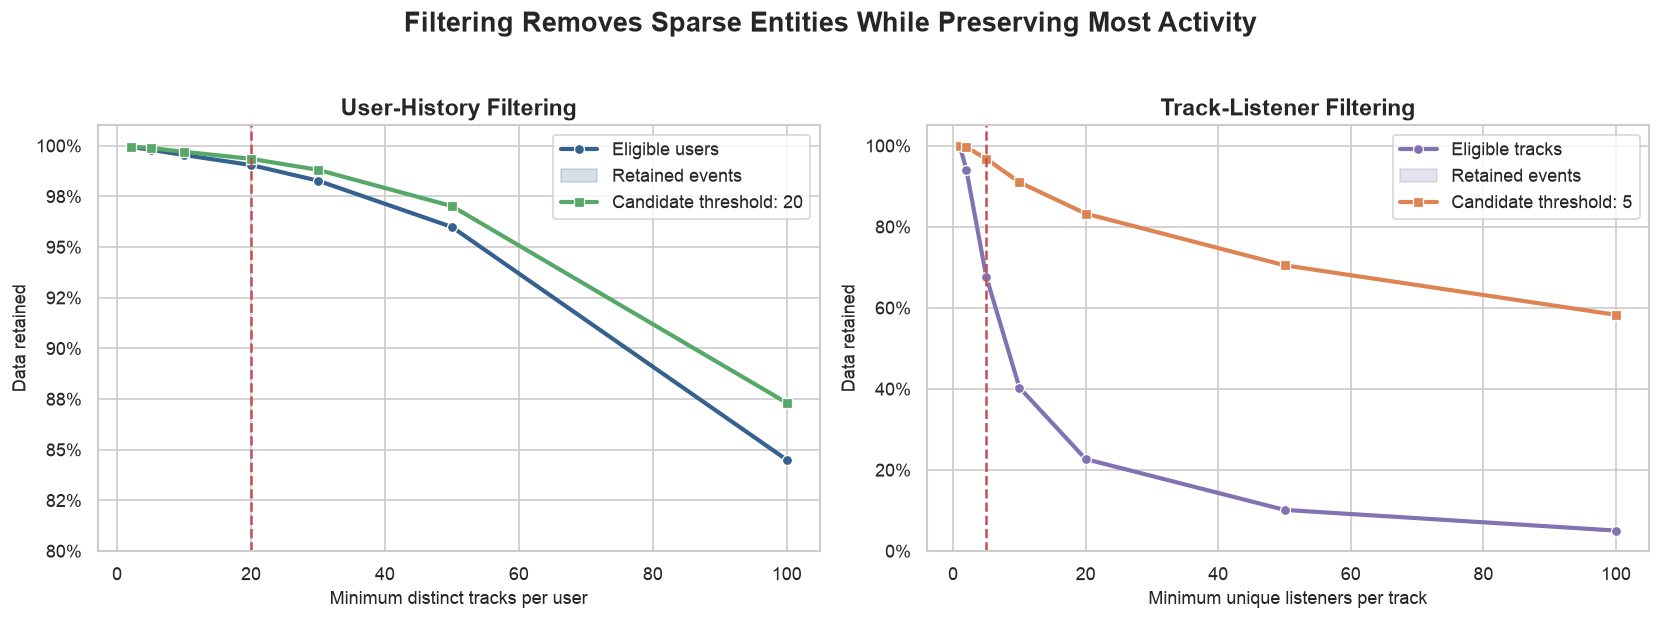

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=user_threshold_plot,
    x="minimum_distinct_tracks",
    y="eligible_user_pct",
    marker="o",
    linewidth=2.5,
    color="#35618f",
    ax=axes[0],
)
sns.lineplot(
    data=user_threshold_plot,
    x="minimum_distinct_tracks",
    y="retained_event_pct",
    marker="s",
    linewidth=2.5,
    color="#55a868",
    ax=axes[0],
)
axes[0].axvline(
    20,
    color="#c44e52",
    linestyle="--",
    label="Candidate threshold: 20",
)
axes[0].set(
    title="User-History Filtering",
    xlabel="Minimum distinct tracks per user",
    ylabel="Data retained",
    ylim=(80, 101),
)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0f}%")
)
axes[0].legend(
    [
        "Eligible users",
        "Retained events",
        "Candidate threshold: 20",
    ]
)

sns.lineplot(
    data=track_thresholds,
    x="minimum_unique_listeners",
    y="eligible_track_pct",
    marker="o",
    linewidth=2.5,
    color="#8172b2",
    ax=axes[1],
)
sns.lineplot(
    data=track_thresholds,
    x="minimum_unique_listeners",
    y="retained_event_pct",
    marker="s",
    linewidth=2.5,
    color="#dd8452",
    ax=axes[1],
)
axes[1].axvline(
    5,
    color="#c44e52",
    linestyle="--",
    label="Candidate threshold: 5",
)
axes[1].set(
    title="Track-Listener Filtering",
    xlabel="Minimum unique listeners per track",
    ylabel="Data retained",
    ylim=(0, 105),
)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0f}%")
)
axes[1].legend(
    [
        "Eligible tracks",
        "Retained events",
        "Candidate threshold: 5",
    ]
)

fig.suptitle(
    "Filtering Removes Sparse Entities While Preserving Most Activity",
    fontsize=16,
    fontweight="bold",
    y=1.03,
)
fig.tight_layout()

figure_path = FIGURE_DIRECTORY / "04_filtering_tradeoffs.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

In [32]:
display(
    user_threshold_plot.rename(
        columns={
            "minimum_distinct_tracks": "Minimum distinct tracks",
            "eligible_users": "Eligible users",
            "eligible_user_pct": "Eligible users (%)",
            "retained_events": "Retained events",
            "retained_event_pct": "Retained events (%)",
        }
    ).style.hide(axis="index").format(
        {
            "Eligible users": "{:,.0f}",
            "Eligible users (%)": "{:.2f}",
            "Retained events": "{:,.0f}",
            "Retained events (%)": "{:.2f}",
        }
    )
)

display(
    track_thresholds.rename(
        columns={
            "minimum_unique_listeners": "Minimum unique listeners",
            "eligible_tracks": "Eligible tracks",
            "eligible_track_pct": "Eligible tracks (%)",
            "retained_events": "Retained events",
            "retained_event_pct": "Retained events (%)",
        }
    ).style.hide(axis="index").format(
        {
            "Eligible tracks": "{:,.0f}",
            "Eligible tracks (%)": "{:.2f}",
            "Retained events": "{:,.0f}",
            "Retained events (%)": "{:.2f}",
        }
    )
)

Minimum distinct tracks,Eligible users,Eligible users (%),Retained events,Retained events (%)
2,"14,119",99.94,"5,025,501",99.96
5,"14,098",99.79,"5,021,703",99.88
10,"14,062",99.54,"5,012,653",99.70
20,"13,992",99.04,"4,994,991",99.35
30,"13,883",98.27,"4,967,777",98.81
50,"13,560",95.99,"4,877,696",97.02
100,"11,937",84.50,"4,389,577",87.31


Minimum unique listeners,Eligible tracks,Eligible tracks (%),Retained events,Retained events (%)
1,"99,596",100.00,"5,027,708",100.00
2,"93,694",94.07,"5,008,748",99.62
5,"67,439",67.71,"4,865,074",96.77
10,"40,162",40.32,"4,573,672",90.97
20,"22,574",22.67,"4,185,029",83.24
50,"10,089",10.13,"3,543,956",70.49
100,"5,005",5.03,"2,929,262",58.26


### Filtering Decision

The initial modeling dataset will require:

- at least **20 distinct tracks per user**;
- at least **5 unique listeners per track**.

The user threshold retains approximately 99% of users and more than 99% of listening events. It ensures that users have enough distinct history for seed sets of up to 10 tracks while preserving future evaluation targets.

The track threshold retains approximately 68% of the catalog but nearly 97% of listening events. This removes tracks with almost no collaborative evidence without eliminating the dataset’s long-tail structure.

These thresholds will be reapplied iteratively because removing tracks can cause some users to fall below the user-history requirement.

## 5. Genre Content Features

The content-based recommender will represent each track using a 685-dimensional genre TF-IDF vector.

These features are especially important during severe cold start because collaborative evidence is limited when only one or a few seed tracks are available.

In [33]:
from IPython.display import HTML


AUDIT_DIRECTORY = PROJECT_ROOT / "reports" / "tables"

genre_dataset_summary = pd.read_csv(
    AUDIT_DIRECTORY / "genre_dataset_summary.csv"
)
genre_feature_catalog = pd.read_csv(
    AUDIT_DIRECTORY / "genre_feature_catalog.csv"
)
genre_feature_summary = pd.read_csv(
    AUDIT_DIRECTORY / "genre_feature_summary.csv"
)
genre_track_summary = pd.read_csv(
    AUDIT_DIRECTORY / "genre_track_summary.csv"
)

print(f"Genre features: {len(genre_feature_catalog):,}")
print(f"Tracks with genre records: {len(genre_track_summary):,}")

Genre features: 685
Tracks with genre records: 109,269


In [34]:
display(
    genre_dataset_summary.rename(
        columns={
            "statistic": "Statistic",
            "value": "Value",
        }
    ).style.hide(axis="index")
)

Statistic,Value
Tracks,109269.000000
Unique track IDs,109269.000000
Duplicate track IDs,0.000000
Missing track IDs,0.000000
Genre features,685.000000
Total feature cells,74849265.000000
Nonzero feature cells,237448.000000
Missing feature cells,0.000000
Negative feature cells,0.000000
Tracks without active genres,27.000000


In [ ]:
genre_catalog_display = genre_feature_catalog.rename(
    columns={
        "feature_number": "Feature number",
        "genre": "Genre",
    }
)

genre_catalog_html = genre_catalog_display.to_html(
    index=False,
    classes="genre-catalog",
)

display(
    HTML(
        """
        <style>
            .genre-catalog {
                border-collapse: collapse;
                width: 100%;
                font-size: 14px;
            }

            .genre-catalog th,
            .genre-catalog td {
                border-bottom: 1px solid #dddddd;
                padding: 7px 12px;
                text-align: left;
            }

            .genre-catalog th {
                position: sticky;
                top: 0;
                background: #f2f2f2;
                z-index: 1;
            }
        </style>

        <h4>Complete Genre Feature Catalog</h4>

        <div style="
            max-height: 420px;
            overflow-y: auto;
            border: 1px solid #dddddd;
            border-radius: 6px;
        ">
        """
        + genre_catalog_html
        + "</div>"
    )
)

*Output intentionally omitted because it displays the complete agreement-protected feature catalog.*

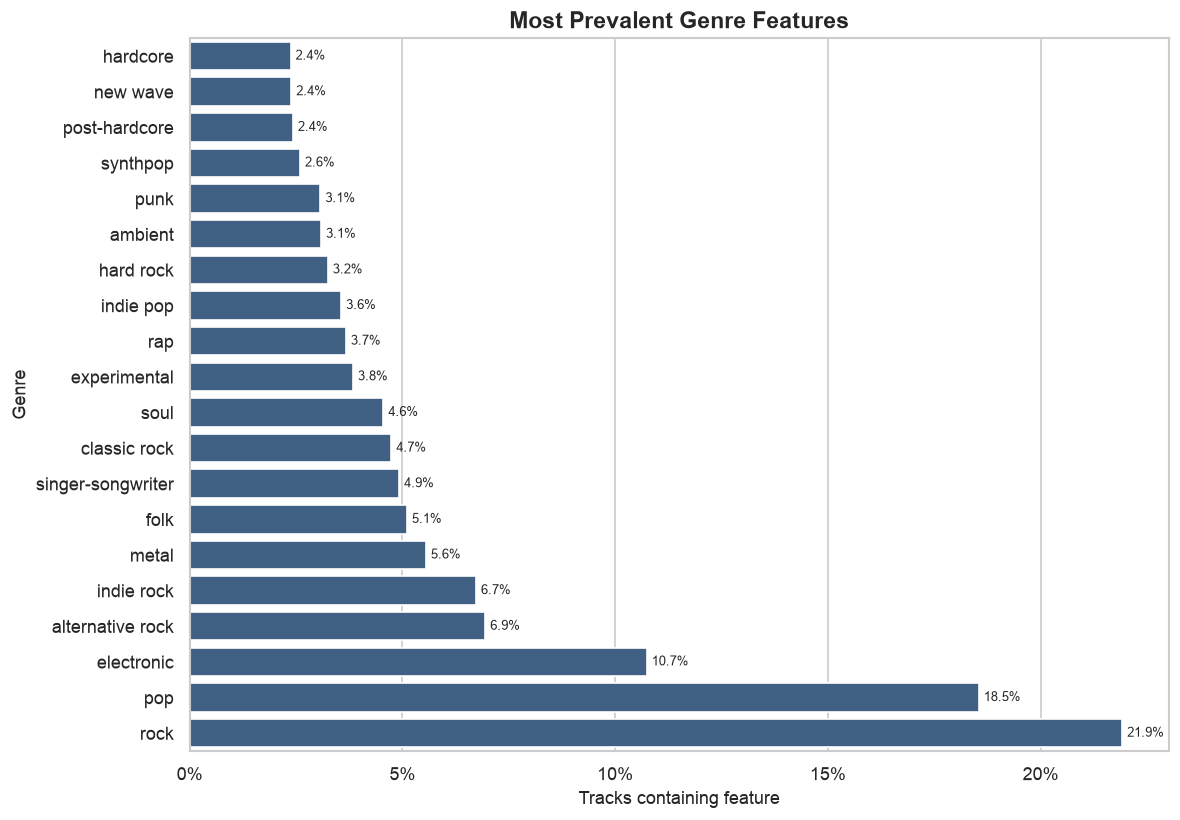

In [36]:
top_genres = (
    genre_feature_summary.head(20)
    .sort_values("track_coverage_pct")
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=top_genres,
    x="track_coverage_pct",
    y="genre",
    color="#35618f",
    ax=ax,
)

ax.set(
    title="Most Prevalent Genre Features",
    xlabel="Tracks containing feature",
    ylabel="Genre",
)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0f}%")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8,
    )

fig.tight_layout()

figure_path = FIGURE_DIRECTORY / "05_genre_prevalence.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

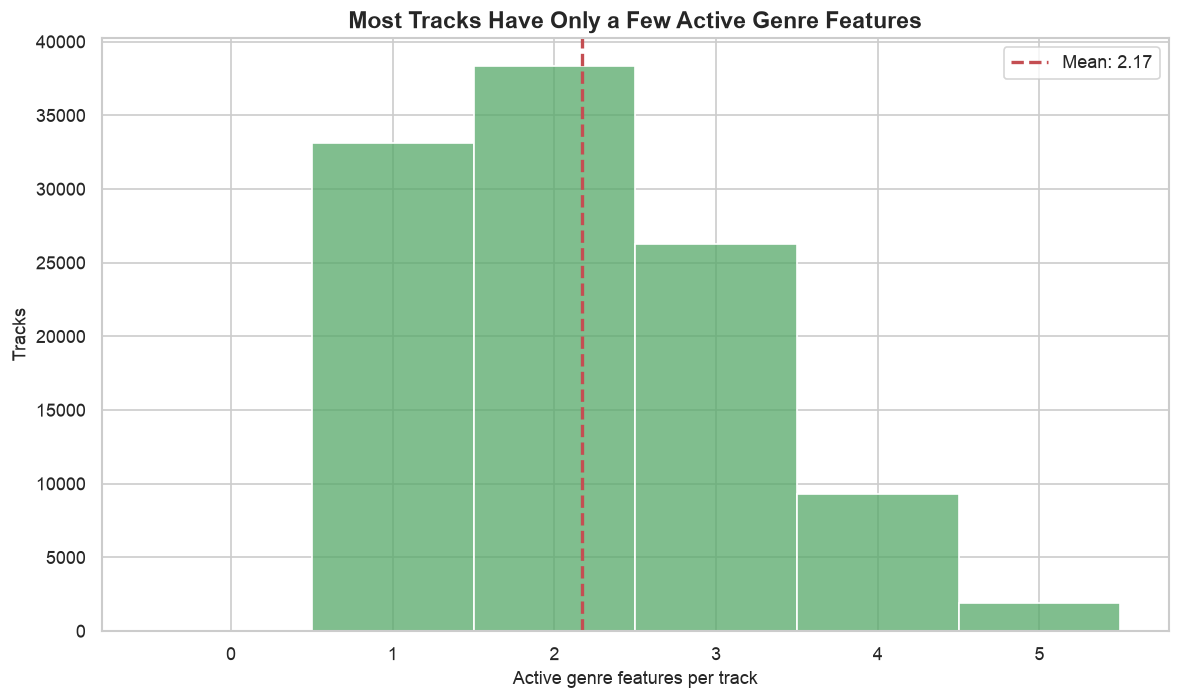

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

maximum_display_count = int(
    genre_track_summary["active_genre_count"]
    .quantile(0.99)
)

sns.histplot(
    data=genre_track_summary[
        genre_track_summary["active_genre_count"]
        <= maximum_display_count
    ],
    x="active_genre_count",
    discrete=True,
    color="#55a868",
    ax=ax,
)

mean_active_genres = (
    genre_track_summary["active_genre_count"].mean()
)

ax.axvline(
    mean_active_genres,
    color="#c44e52",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_active_genres:.2f}",
)

ax.set(
    title="Most Tracks Have Only a Few Active Genre Features",
    xlabel="Active genre features per track",
    ylabel="Tracks",
)
ax.legend()

fig.tight_layout()

figure_path = FIGURE_DIRECTORY / "06_active_genres.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

In [ ]:
tracks_without_genres = genre_track_summary[
    genre_track_summary["active_genre_count"] == 0
]

print(
    "Tracks without active genre features:",
    f"{len(tracks_without_genres):,}",
)

display(tracks_without_genres.head(10))

*Output intentionally omitted because it contains agreement-protected record-level metadata.*

### Findings

- The content representation contains 685 genre features across 109,269 tracks.
- Only approximately 0.32% of feature cells are nonzero, making the matrix more than 99.68% sparse.
- Tracks have approximately 2.17 active genres on average.
- Broad genres such as rock, pop, and electronic appear most frequently, while narrower subgenres provide more distinctive TF-IDF signals.
- Only 27 tracks have all-zero genre vectors. These tracks cannot produce meaningful cosine similarity and will require exclusion or fallback treatment in the content-based model.

The sparse genre matrix should be stored and modeled using sparse numerical structures rather than as a dense track-by-feature array.

## 6. Temporal Coverage

Although the dataset contains a small number of records dating back to 2013, more than 99.9% of listening events occur between December 2018 and March 2019.

The temporal analysis therefore focuses on this dense observation window. Chronological evaluation will order interactions independently within each user, preventing later behavior from leaking into the seed profile.

In [39]:
from music_recommender.eda import load_listening_history


HISTORY_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "music4all"
    / "listening_history.csv"
)

history = load_listening_history(HISTORY_PATH)

history["month"] = (
    history["timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_activity = (
    history.groupby("month", observed=True)
    .agg(
        listening_events=("song", "size"),
        active_users=("user", "nunique"),
        active_tracks=("song", "nunique"),
    )
    .reset_index()
)

analysis_start = pd.Timestamp("2018-12-01")

recent_history = history[
    history["timestamp"] >= analysis_start
].copy()

recent_history["week"] = (
    recent_history["timestamp"]
    .dt.to_period("W")
    .dt.start_time
)

weekly_activity = (
    recent_history.groupby("week")
    .agg(
        listening_events=("song", "size"),
        active_users=("user", "nunique"),
        active_tracks=("song", "nunique"),
    )
    .reset_index()
)

first_user_month = (
    history.groupby("user", observed=True)["month"]
    .min()
    .value_counts()
    .sort_index()
    .rename_axis("month")
    .reset_index(name="new_users")
)

monthly_activity = monthly_activity.merge(
    first_user_month,
    on="month",
    how="left",
)

monthly_activity["new_users"] = (
    monthly_activity["new_users"]
    .fillna(0)
    .astype(int)
)

monthly_activity.head()

Removed 81,884 exact duplicate events.


,month,listening_events,active_users,active_tracks,new_users
0,2013-12-01,13,1,11,1
1,2016-06-01,5,1,5,1
2,2017-05-01,13,1,10,1
3,2017-06-01,3,1,3,1
4,2017-10-01,7,1,6,1


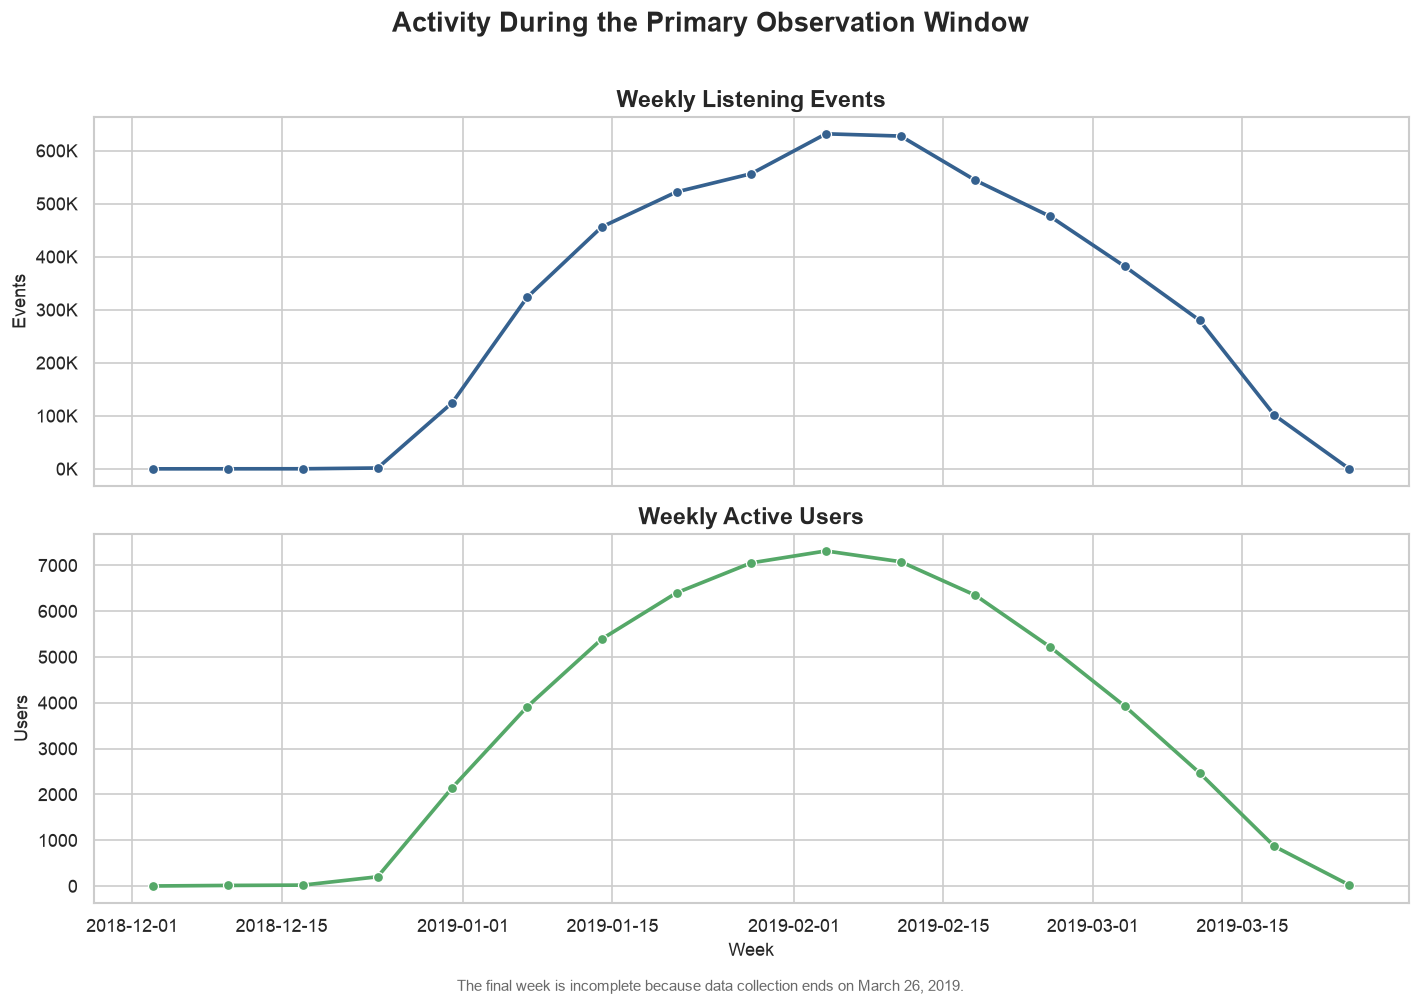

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(
    data=weekly_activity,
    x="week",
    y="listening_events",
    marker="o",
    linewidth=2.2,
    color="#35618f",
    ax=axes[0],
)

axes[0].set(
    title="Weekly Listening Events",
    xlabel="",
    ylabel="Events",
)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000:,.0f}K")
)

sns.lineplot(
    data=weekly_activity,
    x="week",
    y="active_users",
    marker="o",
    linewidth=2.2,
    color="#55a868",
    ax=axes[1],
)

axes[1].set(
    title="Weekly Active Users",
    xlabel="Week",
    ylabel="Users",
)

fig.suptitle(
    "Activity During the Primary Observation Window",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)

fig.text(
    0.5,
    -0.01,
    (
        "The final week is incomplete because data collection "
        "ends on March 26, 2019."
    ),
    ha="center",
    fontsize=9,
    color="dimgray",
)

fig.tight_layout()

figure_path = FIGURE_DIRECTORY / "07_temporal_coverage.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

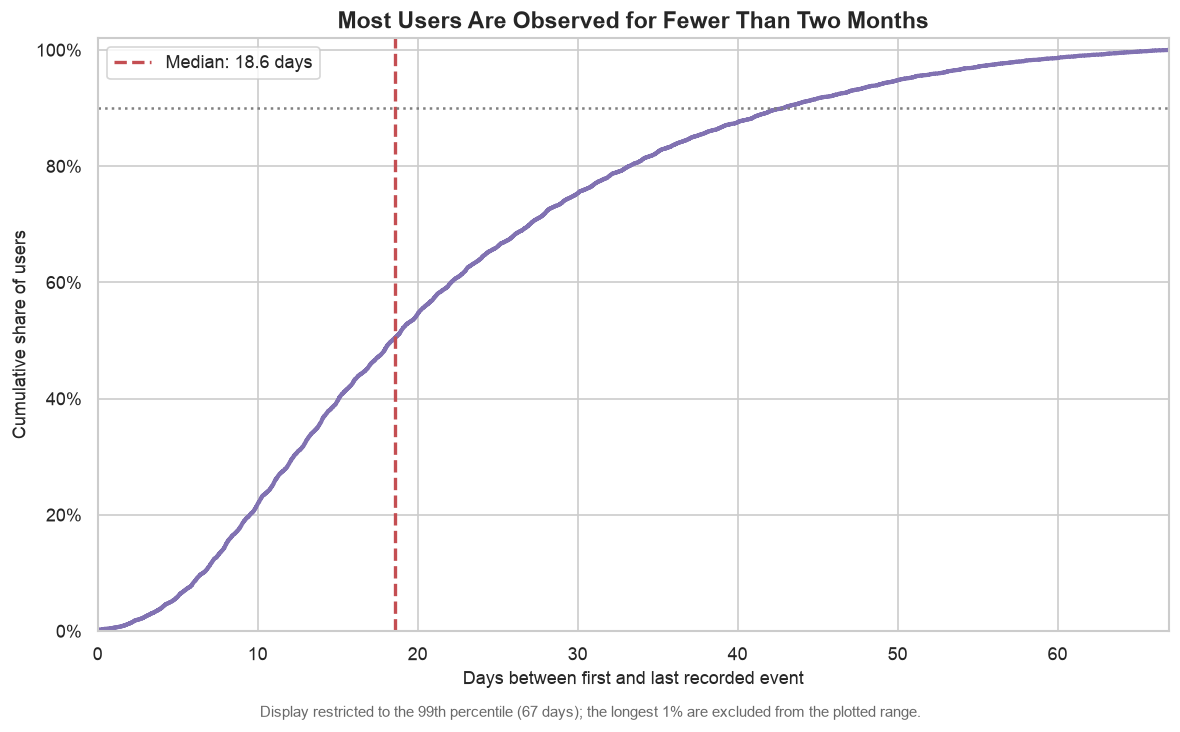

In [41]:
user_time_summary = (
    history.groupby("user", observed=True)
    .agg(
        first_event=("timestamp", "min"),
        last_event=("timestamp", "max"),
        listening_events=("song", "size"),
        distinct_tracks=("song", "nunique"),
    )
    .reset_index()
)

user_time_summary["history_span_days"] = (
    user_time_summary["last_event"]
    - user_time_summary["first_event"]
).dt.total_seconds() / 86_400

fig, ax = plt.subplots(figsize=(10, 6))

span_limit = user_time_summary[
    "history_span_days"
].quantile(0.99)

typical_user_spans = user_time_summary[
    user_time_summary["history_span_days"] <= span_limit
]

sns.ecdfplot(
    data=typical_user_spans,
    x="history_span_days",
    color="#8172b2",
    linewidth=2.5,
    ax=ax,
)

median_span = user_time_summary[
    "history_span_days"
].median()

ax.axvline(
    median_span,
    color="#c44e52",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_span:.1f} days",
)

ax.axhline(
    0.90,
    color="gray",
    linestyle=":",
    linewidth=1.5,
)

ax.set(
    title="Most Users Are Observed for Fewer Than Two Months",
    xlabel="Days between first and last recorded event",
    ylabel="Cumulative share of users",
    xlim=(0, span_limit),
    ylim=(0, 1.02),
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)
ax.legend()

fig.text(
    0.5,
    -0.01,
    (
        "Display restricted to the 99th percentile "
        f"({span_limit:.0f} days); the longest 1% are excluded "
        "from the plotted range."
    ),
    ha="center",
    fontsize=9,
    color="dimgray",
)

fig.tight_layout()

figure_path = FIGURE_DIRECTORY / "08_user_history_spans.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

In [42]:
temporal_summary = pd.DataFrame(
    {
        "Statistic": [
            "Earliest event",
            "Latest event",
            "Observed months",
            "Median events per month",
            "Median active users per month",
            "Median user history span (days)",
        ],
        "Value": [
            history["timestamp"].min(),
            history["timestamp"].max(),
            monthly_activity["month"].nunique(),
            int(monthly_activity["listening_events"].median()),
            int(monthly_activity["active_users"].median()),
            round(
                user_time_summary["history_span_days"].median(),
                1,
            ),
        ],
    }
)

display(temporal_summary.style.hide(axis="index"))

Statistic,Value
Earliest event,2013-12-30 22:42:00
Latest event,2019-03-26 11:57:00
Observed months,15
Median events per month,13
Median active users per month,1
Median user history span (days),18.600000


### Findings

- More than 99.9% of listening events occur between December 2018 and March 2019.
- Only 49 events across 6 users occur before 2018, so the nominal 2013–2019 range does not represent continuous data collection.
- The median user is observed for approximately 19 days.
- Approximately 90% of users are observed for no more than 44 days, and 99% for no more than 67 days.
- The decline in the final week is partly caused by the dataset ending on March 26, 2019.

The dataset is best understood as a dense, short-term listening snapshot. Chronological holdout remains appropriate, but the resulting evaluation measures near-term recommendation performance rather than long-term changes in musical taste.

### Implications for Evaluation

- Interactions must be ordered independently within each user rather than split using one global calendar date.
- Each user’s earliest distinct tracks will form the observed seed set.
- Later distinct tracks will serve as relevant recommendation targets.
- Seed-set sizes of 1, 3, 5, and 10 tracks will simulate progressively weaker cold-start conditions.
- Repeated listens to seed tracks will not be treated as new recommendation targets.
- Tracks unavailable to a fitted model at evaluation time will require explicit accounting rather than silent removal.

This user-relative chronological design reflects the product question: how effectively can the system recommend future discoveries after observing only a small amount of a listener’s history?

## 7. Conclusions

The exploratory analysis supports the following modeling decisions:

1. Remove exact duplicate user–track–timestamp records.
2. Retain users with at least 20 distinct tracks.
3. Retain tracks with at least 5 unique listeners.
4. Reapply these thresholds iteratively until the eligible user and track sets stabilize.
5. Represent content with the sparse 685-feature genre TF-IDF matrix.
6. Evaluate cold start using chronological seed sets of 1, 3, 5, and 10 distinct tracks.
7. Compare recommendation quality against a popularity baseline.
8. Report ranking accuracy alongside novelty, diversity, and catalog coverage.

The dataset’s deep user histories, sparse content features, and highly concentrated track popularity make it appropriate for evaluating hybrid recommendation under realistic cold-start conditions.